# 07. Comunidades

Se detectan comunidades sobre la red construida en el punto 4 y se caracterizan con los videos,
canales, autores, intensidad de participación, vocabulario y una señal preliminar de tono. El
análisis formal de sentimiento corresponde al punto 9.

In [1]:
from pathlib import Path
from collections import Counter
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 70)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
plt.style.use("seaborn-v0_8-whitegrid")

def localizar(nombre, subcarpeta):
    candidatos = [Path.cwd() / subcarpeta / nombre, Path.cwd() / nombre,
                  Path.cwd().parent / subcarpeta / nombre]
    for ruta in candidatos:
        if ruta.exists():
            return ruta
    raise FileNotFoundError(f"No se encontró {nombre}. Ejecute primero los notebooks previos.")

nodos_bip = pd.read_csv(localizar("04_nodos_bipartita.csv", "salidas"), dtype={"raw_id": "string"})
aristas_bip = pd.read_csv(localizar("04_aristas_bipartita.csv", "salidas"))
nodos_aa = pd.read_csv(localizar("05_nodos_autor_autor.csv", "salidas"), dtype={"author_channel_id": "string"})
aristas_aa = pd.read_csv(localizar("05_aristas_autor_autor.csv", "salidas"))
comentarios = pd.read_csv(localizar("02_youtube_comments_limpio.csv", "salidas"),
                          dtype={"video_id": "string", "comment_id": "string",
                                 "author_channel_id": "string", "channel_id": "string"})

B = nx.Graph()
B.add_nodes_from(nodos_bip.loc[nodos_bip["node_type"] == "author", "node_id"], bipartite=0)
B.add_nodes_from(nodos_bip.loc[nodos_bip["node_type"] == "video", "node_id"], bipartite=1)
B.add_weighted_edges_from(aristas_bip[["source", "target", "weight"]].itertuples(index=False, name=None))

G_aa = nx.Graph()
G_aa.add_nodes_from(nodos_aa["author_channel_id"])
G_aa.add_weighted_edges_from(aristas_aa[["source", "target", "weight"]].itertuples(index=False, name=None))

AUTORES = set(nodos_bip.loc[nodos_bip["node_type"] == "author", "node_id"])
VIDEOS = set(nodos_bip.loc[nodos_bip["node_type"] == "video", "node_id"])
info_nodo = nodos_bip.set_index("node_id")

print(f"Bipartita: {B.number_of_nodes()} nodos, {B.number_of_edges()} aristas")
print(f"Proyección autor-autor: {G_aa.number_of_nodes()} nodos, {G_aa.number_of_edges():,} aristas")
print(f"Comentarios con texto limpio: {comentarios['texto_limpio'].notna().sum()} de {len(comentarios)}")

Bipartita: 351 nodos, 343 aristas
Proyección autor-autor: 332 nodos, 10,732 aristas
Comentarios con texto limpio: 400 de 406


## 7.1 Elección de la red

Se detectan comunidades sobre la red bipartita autor-video y no sobre la proyección autor-autor.

La proyección convierte a los comentaristas de cada video en una camarilla completa, lo que crea
aristas que no corresponden a evidencia adicional. Un algoritmo de modularidad sobre esa red
optimiza una estructura que la propia transformación fabricó, y además pierde la distinción entre
los dos tipos de nodo. La red bipartita conserva la información original, las 343 parejas
autor-video observadas, y permite que una comunidad contenga a la vez videos y autores, que es
justamente lo que interesa describir.

La celda siguiente compara ambas opciones antes de decidir.

In [2]:
comunidades_bip = nx.community.louvain_communities(B, weight="weight", seed=42)
comunidades_proj = nx.community.louvain_communities(G_aa, weight="weight", seed=42)

comparacion = pd.DataFrame([
    {"red": "bipartita autor-video",
     "nodos": B.number_of_nodes(), "aristas": B.number_of_edges(),
     "comunidades": len(comunidades_bip),
     "modularidad": nx.community.modularity(B, comunidades_bip, weight="weight"),
     "comunidades de 1 nodo": sum(1 for x in comunidades_bip if len(x) == 1)},
    {"red": "proyección autor-autor",
     "nodos": G_aa.number_of_nodes(), "aristas": G_aa.number_of_edges(),
     "comunidades": len(comunidades_proj),
     "modularidad": nx.community.modularity(G_aa, comunidades_proj, weight="weight"),
     "comunidades de 1 nodo": sum(1 for x in comunidades_proj if len(x) == 1)},
]).set_index("red")
comparacion

,nodos,aristas,comunidades,modularidad,comunidades de 1 nodo
red,,,,,
bipartita autor-video,351,343,17,0.777,0
proyección autor-autor,332,10732,14,0.395,4


La modularidad de 0.777 en la red bipartita frente a 0.395 en la proyección confirma la decisión:
la partición sobre la red original separa mucho mejor la estructura observada, mientras que en la
proyección las camarillas superpuestas producen una partición peor definida y con autores sueltos
como comunidades de un solo nodo.

## 7.2 Algoritmo, supuestos y tratamiento de los pesos

Se aplica Louvain, un método voraz que optimiza modularidad en dos fases repetidas: mueve cada nodo
a la comunidad vecina que más aumenta la modularidad y luego contrae cada comunidad en un nodo.

Supuestos y limitaciones que conviene explicitar:

La modularidad compara las aristas dentro de cada comunidad contra un modelo nulo de conexiones
aleatorias que conserva los grados. Este modelo nulo asume que cualquier par de nodos puede
conectarse, lo que en una red bipartita nunca ocurre entre nodos del mismo tipo. Por eso se reporta
además la modularidad bipartita de Barber, cuyo modelo nulo solo admite pares autor-video.

Louvain es estocástico y sufre el límite de resolución, que impide detectar comunidades más
pequeñas que cierto tamaño relativo. Por eso se verifica la estabilidad con varias semillas y se
contrasta el resultado con un segundo algoritmo, la agregación voraz de modularidad de Clauset,
Newman y Moore.

Los pesos son el número de comentarios de un autor en un video y se usan como peso de arista. Esto
hace que un autor que comenta varias veces el mismo video refuerce su vínculo con ese video, lo que
es coherente con la definición del punto 4. La alternativa binaria trataría igual una y diez
intervenciones.

In [3]:
def modularidad_barber(G, comunidades, autores, videos, weight="weight"):
    m = G.size(weight=weight)
    pertenencia = {n: i for i, comp in enumerate(comunidades) for n in comp}
    fuerza = dict(G.degree(weight=weight))
    q = 0.0
    for i in autores:
        for j in videos:
            if pertenencia[i] != pertenencia[j]:
                continue
            a = G[i][j][weight] if G.has_edge(i, j) else 0.0
            q += a - fuerza[i] * fuerza[j] / m
    return q / m

estabilidad = []
for semilla in range(10):
    particion = nx.community.louvain_communities(B, weight="weight", seed=semilla)
    estabilidad.append({"semilla": semilla, "comunidades": len(particion),
                        "modularidad": nx.community.modularity(B, particion, weight="weight")})
estabilidad = pd.DataFrame(estabilidad)

voraz = nx.community.greedy_modularity_communities(B, weight="weight")

print("Estabilidad de Louvain en 10 semillas")
print(estabilidad.groupby(["comunidades"])["modularidad"].agg(["count", "min", "max"]).to_string())
print(f"\nClauset-Newman-Moore: {len(voraz)} comunidades, "
      f"modularidad {nx.community.modularity(B, voraz, weight='weight'):.4f}")

comunidades = sorted(nx.community.louvain_communities(B, weight="weight", seed=42), key=len, reverse=True)
pertenencia = {n: i + 1 for i, comp in enumerate(comunidades) for n in comp}

print(f"\nPartición seleccionada: {len(comunidades)} comunidades")
print(f"Modularidad estándar: {nx.community.modularity(B, comunidades, weight='weight'):.4f}")
print(f"Modularidad bipartita de Barber: {modularidad_barber(B, comunidades, AUTORES, VIDEOS):.4f}")

Estabilidad de Louvain en 10 semillas
             count   min   max
comunidades                   
17              10 0.777 0.777

Clauset-Newman-Moore: 17 comunidades, modularidad 0.7774

Partición seleccionada: 17 comunidades
Modularidad estándar: 0.7774
Modularidad bipartita de Barber: 0.7774


Louvain devuelve la misma partición de 17 comunidades y la misma modularidad en las 10 semillas, y
el método voraz llega al mismo resultado. Las dos versiones de la modularidad coinciden hasta el
cuarto decimal, de modo que el sesgo del modelo nulo no afecta la lectura en este caso.

## 7.3 Número de comunidades, tamaños y calidad

Cada comentario se asigna a la comunidad de su video. En el 98% de los casos coincide con la
comunidad de su autor; las diferencias corresponden a los autores puente, que quedan asignados a
una sola comunidad aunque participen en varias.

In [4]:
comentarios["comunidad_video"] = ("video::" + comentarios["video_id"]).map(pertenencia)
comentarios["comunidad_autor"] = ("author::" + comentarios["author_channel_id"]).map(pertenencia)
coincidencia = (comentarios["comunidad_video"] == comentarios["comunidad_autor"]).mean()

filas = []
for i, comp in enumerate(comunidades, start=1):
    autores_comp = [n for n in comp if n in AUTORES]
    videos_comp = [n for n in comp if n in VIDEOS]
    sub = comentarios[comentarios["comunidad_video"] == i]
    filas.append({
        "comunidad": i,
        "nodos": len(comp),
        "autores": len(autores_comp),
        "videos": len(videos_comp),
        "comentarios": len(sub),
        "canales": sub["channel_name"].nunique(),
        "comentarios por autor": len(sub) / len(autores_comp) if autores_comp else np.nan,
        "% de comentarios": 100 * len(sub) / len(comentarios),
    })
resumen_comunidades = pd.DataFrame(filas)

print(f"Comunidades detectadas: {len(comunidades)}")
print(f"Coincidencia entre comunidad del video y del autor: {coincidencia:.1%} de los comentarios")
resumen_comunidades

Comunidades detectadas: 17
Coincidencia entre comunidad del video y del autor: 98.0% de los comentarios


,comunidad,nodos,autores,videos,comentarios,canales,comentarios por autor,% de comentarios
0,1,126,125,1,161,1,1.288,39.655
1,2,48,47,1,50,1,1.064,12.315
2,3,32,29,3,34,1,1.172,8.374
3,4,31,30,1,45,1,1.500,11.084
4,5,26,25,1,25,1,1.000,6.158
5,6,19,18,1,25,1,1.389,6.158
6,7,19,18,1,25,1,1.389,6.158
7,8,14,13,1,14,1,1.077,3.448
8,9,8,7,1,7,1,1.000,1.724
9,10,8,7,1,7,1,1.000,1.724


## 7.4 Visualización de todas las comunidades

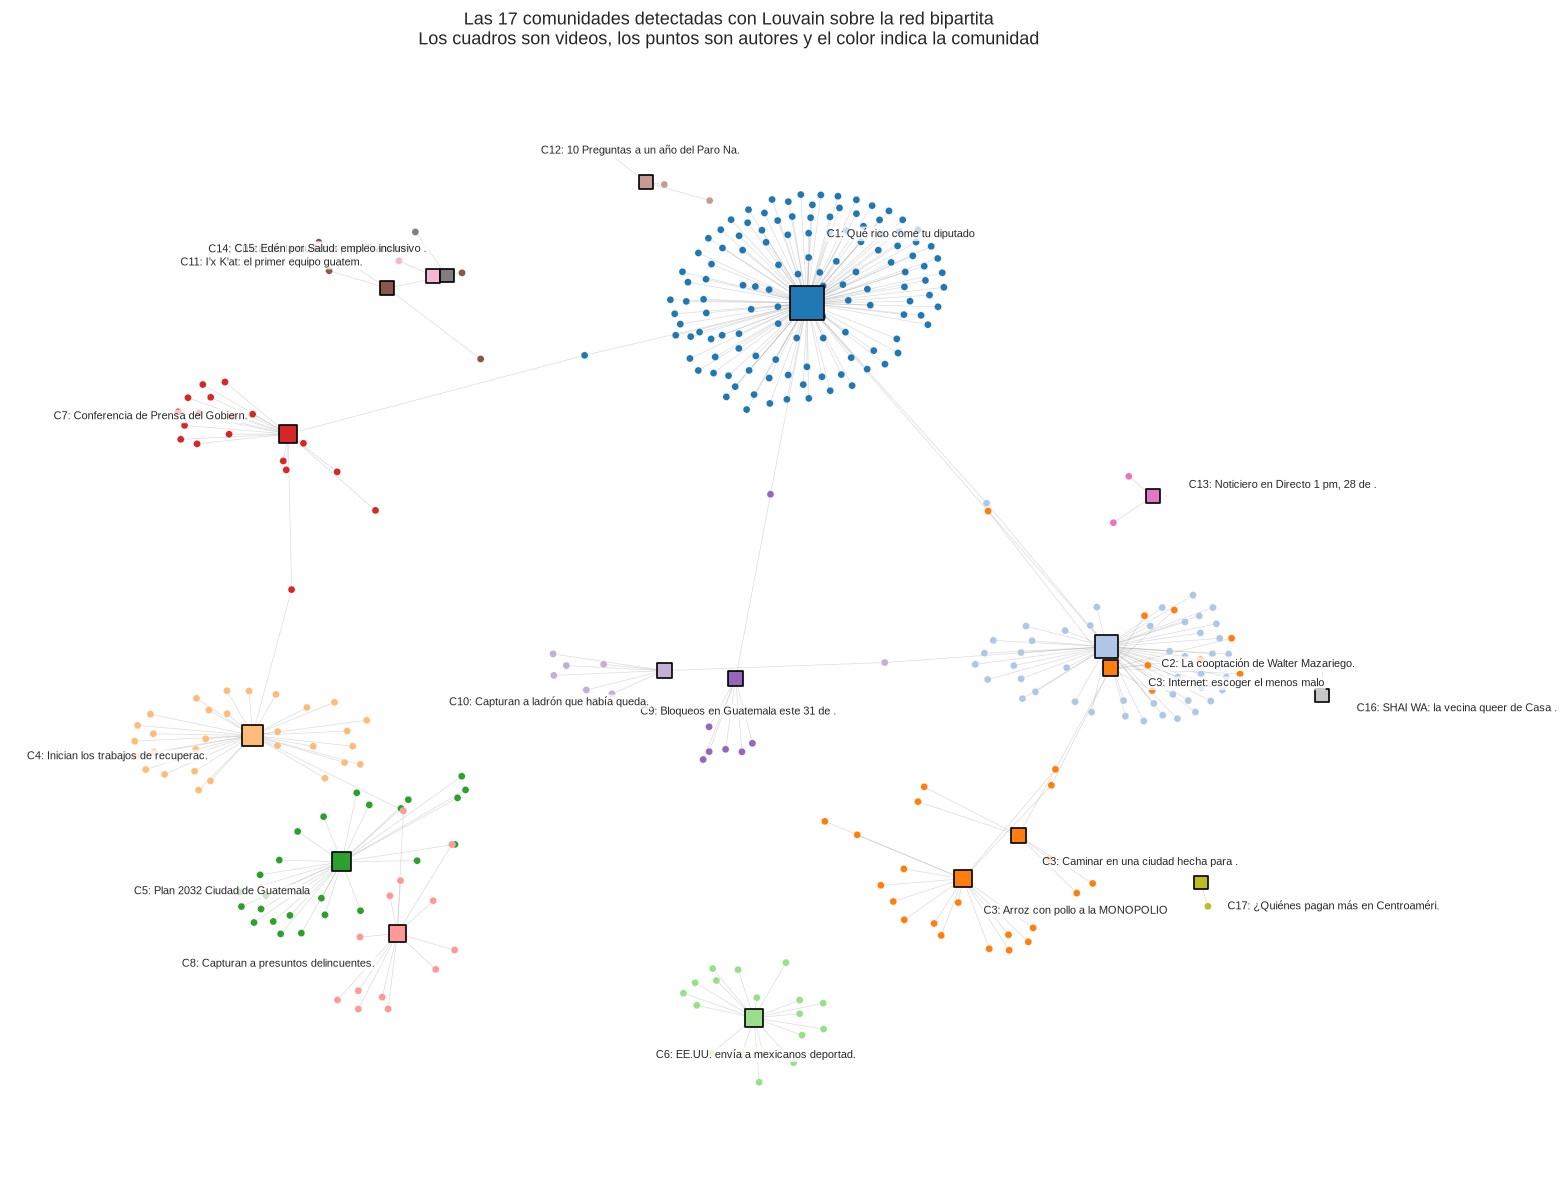

In [5]:
PALETA = plt.get_cmap("tab20").colors
color_comunidad = {i + 1: PALETA[i % len(PALETA)] for i in range(len(comunidades))}

posiciones = nx.spring_layout(B, weight="weight", k=0.55, iterations=250, seed=5)
autores_lista = [n for n in B.nodes() if n in AUTORES]
videos_lista = sorted((n for n in B.nodes() if n in VIDEOS),
                      key=lambda v: -info_nodo.loc[v, "unique_authors"])

fig, ax = plt.subplots(figsize=(16, 12))
nx.draw_networkx_edges(B, posiciones, ax=ax, edge_color="#9A9A9A", alpha=0.35, width=0.5)
nx.draw_networkx_nodes(B, posiciones, ax=ax, nodelist=autores_lista, node_size=26,
                       node_color=[color_comunidad[pertenencia[n]] for n in autores_lista],
                       linewidths=0.2, edgecolors="white")
nx.draw_networkx_nodes(B, posiciones, ax=ax, nodelist=videos_lista, node_shape="s",
                       node_size=[90 + 4 * info_nodo.loc[n, "unique_authors"] for n in videos_lista],
                       node_color=[color_comunidad[pertenencia[n]] for n in videos_lista],
                       linewidths=1.2, edgecolors="black")

def recortar(texto, n=34):
    texto = str(texto)
    return texto if len(texto) <= n else texto[:n - 1] + "."

centro = np.mean([posiciones[n] for n in B.nodes()], axis=0)
for n in videos_lista:
    x, y = posiciones[n]
    direccion = np.array([x, y]) - centro
    direccion = direccion / (np.linalg.norm(direccion) or 1)
    radio = 0.05 + 0.0006 * info_nodo.loc[n, "unique_authors"]
    ax.text(x + radio * direccion[0], y + radio * direccion[1],
            f"C{pertenencia[n]}: {recortar(info_nodo.loc[n, 'label'])}",
            fontsize=8,
            ha="left" if direccion[0] > 0.2 else ("right" if direccion[0] < -0.2 else "center"),
            va="bottom" if direccion[1] >= 0 else "top",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75))

ax.set_title(f"Las {len(comunidades)} comunidades detectadas con Louvain sobre la red bipartita\n"
             "Los cuadros son videos, los puntos son autores y el color indica la comunidad", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()

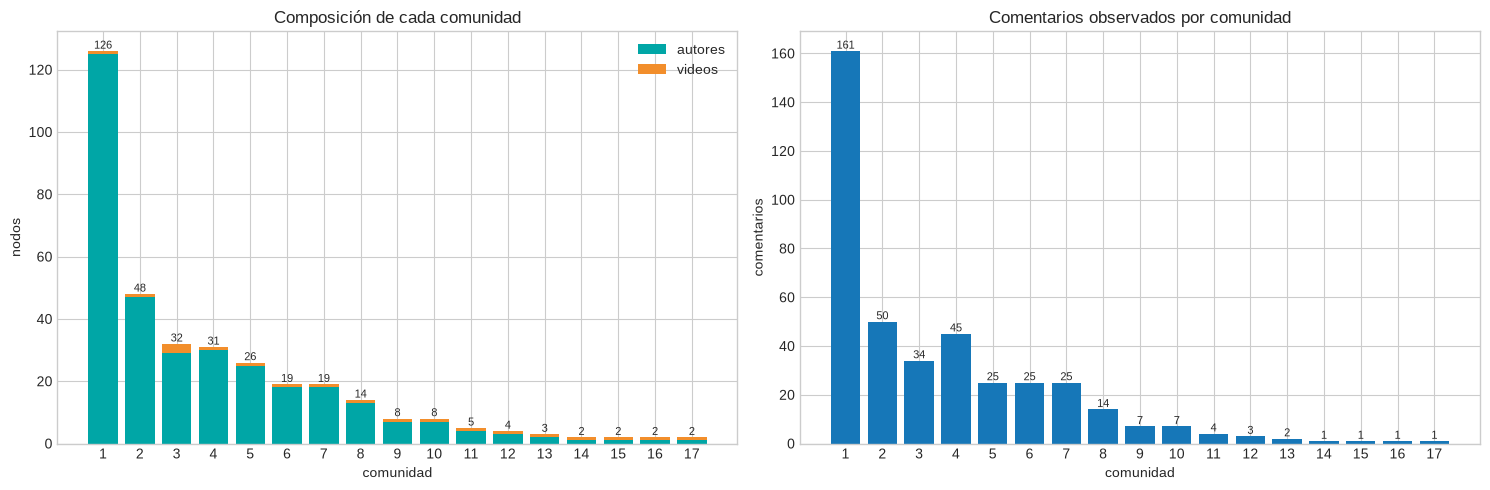

In [6]:
fig, ejes = plt.subplots(1, 2, figsize=(15, 5))

x = resumen_comunidades["comunidad"]
ejes[0].bar(x, resumen_comunidades["autores"], color="#00A6A6", label="autores")
ejes[0].bar(x, resumen_comunidades["videos"], bottom=resumen_comunidades["autores"],
            color="#F28E2B", label="videos")
for _, fila in resumen_comunidades.iterrows():
    ejes[0].text(fila["comunidad"], fila["nodos"], f"{int(fila['nodos'])}",
                 ha="center", va="bottom", fontsize=8)
ejes[0].set_title("Composición de cada comunidad")
ejes[0].set_xlabel("comunidad")
ejes[0].set_ylabel("nodos")
ejes[0].set_xticks(x)
ejes[0].legend()

ejes[1].bar(x, resumen_comunidades["comentarios"], color="#1677B8")
for _, fila in resumen_comunidades.iterrows():
    ejes[1].text(fila["comunidad"], fila["comentarios"], f"{int(fila['comentarios'])}",
                 ha="center", va="bottom", fontsize=8)
ejes[1].set_title("Comentarios observados por comunidad")
ejes[1].set_xlabel("comunidad")
ejes[1].set_ylabel("comentarios")
ejes[1].set_xticks(x)

plt.tight_layout()
plt.show()

## 7.5 Caracterización de las comunidades

El vocabulario se obtiene de `texto_limpio`, ya sin stopwords ni puntuación. La señal de tono usa
el mismo léxico exploratorio del punto 3: cuenta palabras marcadas como positivas o negativas y
devuelve su balance. No resuelve negación, ironía ni emojis, por lo que se reporta como indicio y
no como clasificación de sentimiento; el punto 9 aplica la herramienta adecuada para español.

In [7]:
LEX_POS = set("excelente bien bueno buena buenos buenas gracias apoyo viva bendiciones belleza "
              "felicidades correcto correcta mejor genial increíble maravilloso orgullo felicito "
              "éxito éxitos importante interesante".split())
LEX_NEG = set("corrupto corruptos corrupción robo ladrón ladrones malo mala mal pena asco mentira "
              "mentiras odio problema problemas hambre inútil inútiles mediocre mediocres basura "
              "vergüenza sinvergüenza fraude impunidad".split())

def señal_tono(textos):
    palabras = Counter(w for t in textos.dropna() for w in str(t).split())
    pos = sum(palabras[w] for w in LEX_POS)
    neg = sum(palabras[w] for w in LEX_NEG)
    balance = (pos - neg) / (pos + neg) if pos + neg else np.nan
    return pos, neg, balance

def palabras_frecuentes(textos, n=6):
    cuenta = Counter(w for t in textos.dropna() for w in str(t).split() if len(w) > 3)
    return ", ".join(w for w, _ in cuenta.most_common(n))

def bigramas_frecuentes(textos, n=3):
    cuenta = Counter()
    for t in textos.dropna():
        palabras = [w for w in str(t).split() if len(w) > 2]
        cuenta.update(zip(palabras, palabras[1:]))
    return ", ".join(" ".join(b) for b, _ in cuenta.most_common(n))

filas = []
for i, comp in enumerate(comunidades, start=1):
    sub = comentarios[comentarios["comunidad_video"] == i]
    videos_comp = sorted((n for n in comp if n in VIDEOS),
                         key=lambda v: -info_nodo.loc[v, "unique_authors"])
    pos, neg, balance = señal_tono(sub["texto_limpio"])
    filas.append({
        "comunidad": i,
        "videos": " | ".join(str(info_nodo.loc[v, "label"])[:30] for v in videos_comp),
        "canales": " | ".join(sorted(sub["channel_name"].dropna().unique())),
        "autores": sum(1 for n in comp if n in AUTORES),
        "comentarios": len(sub),
        "me gusta": int(sub["like_count"].sum()),
        "respuestas": int(sub["reply_count"].sum()),
        "palabras frecuentes": palabras_frecuentes(sub["texto_limpio"]),
        "bigramas": bigramas_frecuentes(sub["texto_limpio"]),
        "señales +": pos,
        "señales -": neg,
        "balance de tono": balance,
    })
caracterizacion = pd.DataFrame(filas)
caracterizacion.set_index("comunidad")[
    ["videos", "canales", "autores", "comentarios", "me gusta", "señales +", "señales -", "balance de tono"]
]

,videos,canales,autores,comentarios,me gusta,señales +,señales -,balance de tono
comunidad,,,,,,,,
1,Qué rico come tu diputado,Quorum,125,161,358,30,49,-0.241
2,La cooptación de Walter Mazari,Quorum,47,50,91,14,17,-0.097
3,Arroz con pollo a la MONOPOLIO | Internet: escoger el menos mal | ...,Quorum,29,34,17,21,5,0.615
4,Inician los trabajos de recupe,Gobierno de la República de Guatemala,30,45,90,19,8,0.407
5,Plan 2032 Ciudad de Guatemala,Municipalidad de Guatemala,25,25,1697,10,1,0.818
6,EE.UU. envía a mexicanos depor,Noticias Telemundo,18,25,25,5,3,0.250
7,Conferencia de Prensa del Gobi,Gobierno de la República de Guatemala,18,25,20,6,2,0.500
8,Capturan a presuntos delincuen,Noti7,13,14,12,2,0,1.000
9,Bloqueos en Guatemala este 31,PrensaLibreOficial,7,7,1,1,0,1.000


In [8]:
pd.set_option("display.max_colwidth", 120)
caracterizacion.set_index("comunidad")[["palabras frecuentes", "bigramas"]]

,palabras frecuentes,bigramas
comunidad,,
1,"pueblo, dinero, diputados, trabajo, diputado, sueldo","nery rodas, busquen trabajo, paguen sueldo"
2,"usac, corruptos, universidad, estudiantes, excelente, información","pacto corruptos, reuniones virtuales, san carlos"
3,"excelente, empresas, internet, país, información, competencia","ley competencia, libre mercado, excelente video"
4,"presidente, años, guatemala, bernardo, arevalo, proyecto","presidente bernardo, bernardo arevalo, apoyo presidente"
5,"guatemala, ciudad, saludos, viva, proyectos, tiempo","ciudad guatemala, guatemala saludos, viva guatemala"
6,"pais, país, bueno, deportan, personas, mexicanos","you don, entraron ilegalmente, pais pertenesen"
7,"país, guatemala, presidente, personas, gobierno, maya","bla bla, tren maya, siii tanta"
8,"trabajo, vestido, mujer, faltar, cara, jóvenes","jóvenes buscan, buscan trabajo, trabajo tuvieron"
9,"asquerosos, gasolina, subira, guerra, países, guatemala","puro show, show diputranzas, diputranzas den"


In [9]:
pd.set_option("display.max_colwidth", 70)
for i in resumen_comunidades.sort_values("comentarios", ascending=False)["comunidad"].head(3):
    comp = comunidades[i - 1]
    sub = comentarios[comentarios["comunidad_video"] == i]
    videos_comp = sorted((n for n in comp if n in VIDEOS), key=lambda v: -info_nodo.loc[v, "unique_authors"])
    autores_comp = [n for n in comp if n in AUTORES]
    recurrentes = (sub.groupby(["author_channel_id", "author_name"]).size()
                   .sort_values(ascending=False).head(3))
    pos, neg, balance = señal_tono(sub["texto_limpio"])
    print(f"Comunidad {i}: {len(autores_comp)} autores, {len(videos_comp)} videos, {len(sub)} comentarios "
          f"({100 * len(sub) / len(comentarios):.1f}% del total)")
    for v in videos_comp:
        fila = info_nodo.loc[v]
        print(f"   Video: {fila['label']} | canal {fila['channel_name']} | "
              f"{int(fila['unique_authors'])} autores | {int(fila['view_count']):,} vistas")
    print(f"   Intensidad: {len(sub) / len(autores_comp):.2f} comentarios por autor, "
          f"{sub['like_count'].sum()} me gusta, {int(sub['reply_count'].sum())} respuestas")
    print(f"   Autores más activos: " + ", ".join(f"{nombre} ({n})" for (_, nombre), n in recurrentes.items()))
    print(f"   Palabras: {palabras_frecuentes(sub['texto_limpio'], 8)}")
    print(f"   Bigramas: {bigramas_frecuentes(sub['texto_limpio'], 4)}")
    print(f"   Tono preliminar: {pos} señales positivas, {neg} negativas, balance {balance:.2f}")
    print()

Comunidad 1: 125 autores, 1 videos, 161 comentarios (39.7% del total)
   Video: Qué rico come tu diputado | canal Quorum | 128 autores | 11,775 vistas
   Intensidad: 1.29 comentarios por autor, 358 me gusta, 3 respuestas
   Autores más activos: @ManuelEdran (5), @ErvinLeonardoCarreraLatín (4), @osmanmorales3012 (3)
   Palabras: pueblo, dinero, diputados, trabajo, diputado, sueldo, corruptos, almuerzo
   Bigramas: nery rodas, busquen trabajo, paguen sueldo, dinero pueblo
   Tono preliminar: 30 señales positivas, 49 negativas, balance -0.24

Comunidad 2: 47 autores, 1 videos, 50 comentarios (12.3% del total)
   Video: La cooptación de Walter Mazariegos en la USAC | canal Quorum | 49 autores | 10,156 vistas
   Intensidad: 1.06 comentarios por autor, 91 me gusta, 0 respuestas
   Autores más activos: @Jel.Awesh.M (2), @HectorCarranza-u4j4o (1), @RauldejesusOlivagonzalez (1)
   Palabras: usac, corruptos, universidad, estudiantes, excelente, información, fuera, pueblo
   Bigramas: pacto corru

Las tres comunidades con más participación observada son la 1, la 2 y la 4.

Comunidad 1, el público del video "Qué rico come tu diputado" de Quorum. Concentra 125 autores y
161 comentarios, el 39.7% de los observados, y 358 me gusta. El video tiene 128 comentaristas
únicos: tres quedaron asignados a otra comunidad porque también participaron en otros videos. El
vocabulario gira sobre `pueblo`, `dinero`, `diputados` y `sueldo`, con bigramas como
`busquen trabajo` y `paguen sueldo`. El balance de tono es negativo, -0.24, y está dirigido a los
diputados, no a otros comentaristas.

Comunidad 2, el video sobre la cooptación de la USAC, también de Quorum: 47 autores, 50
comentarios y 1.06 comentarios por autor. El vocabulario es institucional (`usac`, `universidad`,
`estudiantes`, `corruptos`, `pacto corruptos`) y el balance de tono queda casi neutro, -0.10,
porque se mezclan la crítica al caso y los elogios al trabajo periodístico (`excelente vídeo`).

Comunidad 4, el video del Gobierno de la República sobre el Puente Belice II: 30 autores y 45
comentarios, con la mayor intensidad de toda la muestra, 1.50 comentarios por autor, y 11
respuestas. El vocabulario se concentra en `presidente`, `bernardo`, `arevalo` y `proyecto`, con
bigramas como `apoyo presidente`. Su balance de tono es positivo, 0.41, y contrasta con las dos
comunidades anteriores.

Caso aparte, la comunidad 3 es la única que agrupa más de un video: tres piezas de Quorum sobre
internet, transporte y precios que quedaron unidas porque dos pares de autores comentaron en dos de
ellas. Es el único lugar de la muestra donde la coparticipación, y no un solo contenido, define la
comunidad. Su vocabulario es temático (`internet`, `empresas`, `competencia`) y su tono es el más
positivo de este grupo, 0.61.

In [10]:
SALIDAS = Path.cwd() / "salidas"
SALIDAS.mkdir(exist_ok=True)

asignacion = nodos_bip[["node_id", "node_type", "raw_id", "label"]].copy()
asignacion["comunidad"] = asignacion["node_id"].map(pertenencia)
asignacion.to_csv(SALIDAS / "07_comunidades_nodos.csv", index=False)

comentarios[["comment_id", "video_id", "author_channel_id", "comunidad_video", "comunidad_autor"]]     .to_csv(SALIDAS / "07_comunidades_comentarios.csv", index=False)
caracterizacion.to_csv(SALIDAS / "07_caracterizacion_comunidades.csv", index=False)
print("Asignación de comunidades y caracterización exportadas en ./salidas/")

Asignación de comunidades y caracterización exportadas en ./salidas/


Sobre la interpretación de estas comunidades. Con excepción de la comunidad 3, cada comunidad
corresponde a un solo video con su público. Esto no es un defecto del algoritmo sino la estructura
real de los datos: casi ningún autor participa en más de un video, de modo que la única frontera
que el algoritmo puede encontrar es la del contenido. Las comunidades describen públicos de un
video, no grupos de personas que conversen entre sí.